#### Logistic Regression
This is manually implemented logistic regression classifier.<br>
Logistic regression is a classification algorithm (not regression despite misleading name).<br>
It is a probabilistic classifier that models probability of an input belonging to a class (f.ex. binary -> 0 or 1).<br>

In [ ]:
import numpy as np
a
class ManualLogisticRegression:

    def __init__(self, lr=0.01, n_iter=1000):
        self.lr = lr
        self.n_iter = n_iter
        self.weights = None
        self.bias = None

    def sigmoid(self, z):
        return 1 / (1 + np.exp(-z))

    def loss(self, y, y_hat):
        eps = 1e-9
        return -np.mean(
            y*np.log(y_hat + eps) +
            (1-y)*np.log(1 - y_hat + eps)
        )


In [137]:
# Gradient Descent Training Loop

def fit(self, X, y):
    n_samples, n_features = X.shape
    self.weights = np.zeros(n_features)
    self.bias = 0

    for _ in range(self.n_iter):          
        linear = np.dot(X, self.weights) + self.bias
        y_hat = self.sigmoid(linear)

        dw = (1/n_samples) * np.dot(X.T, (y_hat - y))
        db = (1/n_samples) * np.sum(y_hat - y)
        self.weights -= self.lr * dw
        self.bias -= self.lr * db

def predict(self, x):                     
    linear = np.dot(x, self.weights) + self.bias
    y_hat = self.sigmoid(linear)
    return (y_hat > 0.5).astype(int)

There are few 'lovely' problems to fix such as naming convention and the approach with files and models.<br>
The fact that writing everything in the one jupyter notebook is not ideal calls for a change but for now it will be kept like this for readability of anyone visiting here.<br> 

In [138]:
import numpy as np

class ManualLogisticRegression:

    def __init__(self, lr=0.01, n_iter=1000):
        self.lr = lr
        self.n_iter = n_iter
        self.weights = None
        self.bias = None

    def sigmoid(self, z):
        return 1 / (1 + np.exp(-z))

    def loss(self, y, y_hat):
        eps = 1e-9
        return -np.mean(
            y*np.log(y_hat + eps) +
            (1-y)*np.log(1 - y_hat + eps)
        )

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0

        for _ in range(self.n_iter):
            linear = np.dot(X, self.weights) + self.bias
            y_hat = self.sigmoid(linear)

            dw = (1/n_samples) * np.dot(X.T, (y_hat - y))
            db = (1/n_samples) * np.sum(y_hat - y)
            self.weights -= self.lr * dw
            self.bias -= self.lr * db

    def predict(self, x):
        linear = np.dot(x, self.weights) + self.bias
        y_hat = self.sigmoid(linear)
        return (y_hat > 0.5).astype(int)

In [139]:
import numpy as np
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

data = load_iris()
X = data.data
y = data.target
X = X[y != 2]
y = y[y != 2]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = ManualLogisticRegression(lr=0.1, n_iter=2000)
model.fit(X_train, y_train)  

preds = model.predict(X_test)

accuracy = np.mean(preds == y_test)
print("Accuracy:", accuracy)

Accuracy: 1.0


#### Visualisation of Iris Dataset

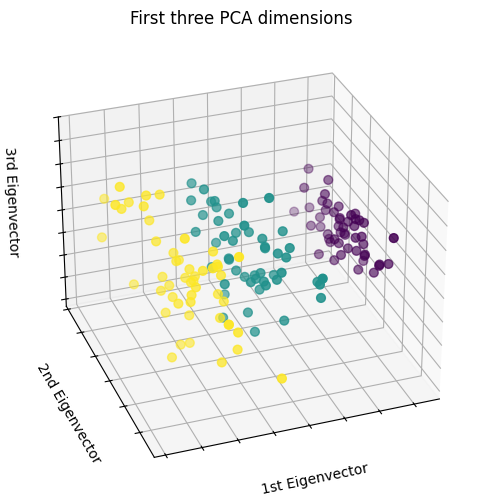

In [140]:
#PCA representation of Iris database which we will be using for our Logistic Regression project
import mpl_toolkits.mplot3d  # noqa: F401
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn import datasets

iris = datasets.load_iris()
fig = plt.figure(1, figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d", elev=-150, azim=110)

X_reduced = PCA(n_components=3).fit_transform(iris.data)
ax.scatter(
    X_reduced[:, 0],
    X_reduced[:, 1],
    X_reduced[:, 2],
    c=iris.target,
    s=40,
)

ax.set_title("First three PCA dimensions")
ax.set_xlabel("1st Eigenvector")
ax.xaxis.set_ticklabels([])
ax.set_ylabel("2nd Eigenvector")
ax.yaxis.set_ticklabels([])
ax.set_zlabel("3rd Eigenvector")
ax.zaxis.set_ticklabels([])

plt.show()

## 1.0 Accuracy Problem
The problem here is we are using only 2 out of 3 classes from Iris Dataset.<br>
We used classes 0 and 1 (setosa and versicolor), these two classes are LINEARLY separeble - meaning a straight line can be drawn to divide them.<br>(this is also EXACTLY what logistic regression does.)<br>
We can see that in our 'Visualisation of Iris Dataset' cell. - These two classes form 2 clean, non-overlapping clusters.<br><br>
At the end, since this is a small, mini-example, we will do following things in the end to make this <i>Machine Learning Concept Display</i> a little bit more interesting:<br>
1. We will use all 3 classes of Iris (this is gonna be interesting since logistic regression is binary).<br>
2. We will use dataset that is not linearly separable, the accuract will drop before 1.0 we will see more realistic behaviour of this model.<br>
3. We will intentionally add noise to the data.<br>

Accuracy: 1.0
Accuracy: 0.86


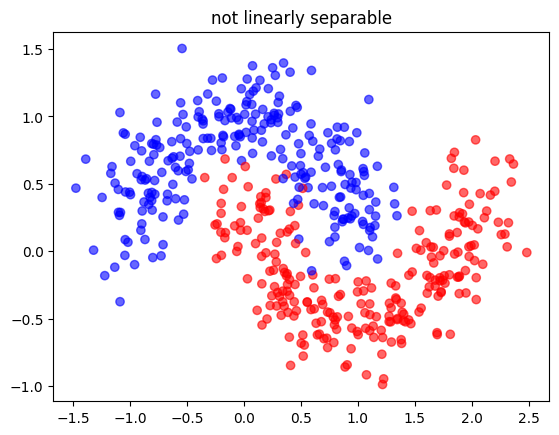

Accuracy: 0.9


In [141]:
import numpy as np

class ManualLogisticRegression:

    def __init__(self, lr=0.01, n_iter=1000):
        self.lr = lr
        self.n_iter = n_iter
        self.weights = None
        self.bias = None

    def sigmoid(self, z):
        return 1 / (1 + np.exp(-z))

    def loss(self, y, y_hat):
        eps = 1e-9
        return -np.mean(
            y*np.log(y_hat + eps) +
            (1-y)*np.log(1 - y_hat + eps)
        )

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0

        for _ in range(self.n_iter):
            linear = np.dot(X, self.weights) + self.bias
            y_hat = self.sigmoid(linear)

            dw = (1/n_samples) * np.dot(X.T, (y_hat - y))
            db = (1/n_samples) * np.sum(y_hat - y)
            self.weights -= self.lr * dw
            self.bias -= self.lr * db

    def predict(self, x):
        linear = np.dot(x, self.weights) + self.bias
        y_hat = self.sigmoid(linear)
        return (y_hat > 0.5).astype(int)


class ManualOvRLogisticRegression:

    def __init__(self, lr=0.01, n_iter=1000):
        self.lr = lr
        self.n_iter = n_iter
        self.models = []

    def fit(self, X, y):
        self.classes = np.unique(y)
        for c in self.classes:
            binary_y = (y == c).astype(int)
            model = ManualLogisticRegression(self.lr, self.n_iter)
            model.fit(X, binary_y)
            self.models.append(model)

    def predict(self, X):
        probs = np.column_stack([
            model.sigmoid(np.dot(X, model.weights) + model.bias)
            for model in self.models
        ])
        return self.classes[np.argmax(probs, axis=1)]

iris = load_iris()
X, y = iris.data, iris.target 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = ManualOvRLogisticRegression(lr=0.1, n_iter=2000)
model.fit(X_train, y_train)
preds = model.predict(X_test)
print("Accuracy:", np.mean(preds == y_test)) 


from sklearn.datasets import make_moons

X, y = make_moons(n_samples=500, noise=0.2, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = ManualLogisticRegression(lr=0.1, n_iter=2000)
model.fit(X_train, y_train)
preds = model.predict(X_test)
print("Accuracy:", np.mean(preds == y_test)) 

import matplotlib.pyplot as plt
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr', alpha=0.6)
plt.title("not linearly separable")
plt.show()

iris = load_iris()
X, y = iris.data, iris.target
X = X[y != 2]
y = y[y != 2]


noise = np.random.normal(loc=0, scale=1.5, size=X.shape)
X_noisy = X + noise

X_train, X_test, y_train, y_test = train_test_split(X_noisy, y, test_size=0.2, random_state=42)

model = ManualLogisticRegression(lr=0.1, n_iter=2000)
model.fit(X_train, y_train)
preds = model.predict(X_test)
print("Accuracy:", np.mean(preds == y_test)) 

### Conclusions and improvement
Since it is pain in the ass to keep everything in one jupyter notebook (has its plusses for readability of the viewer), we will keep proper convention of having models, classes ans other relevant code separated in .py files.<br>
We will make sure to have better writing explanations so in case if someone wants to learn from these project and understand them it will be described accordingly.<br>
As for logistic regression, this particulat example is quite boring (maybe with exception of Iris dataset from sklearn) - especially when compared to project from 1 to 10 in the main portfolio.<br>
On the MP2 you can expect K-Nearest Neighbours written from scratch.<br>
According to the loose plan after the first week of mini-project there will be medium sized and larger project (few days of work ~- week)<br>